In [1]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay)
import seaborn as sns

In [2]:
data = []
labels = []
file_name = []

IMG_SIZE = (128, 128)

for sub_folder in os.listdir("dataset"):
    sub_folder_files = os.listdir(os.path.join("dataset", sub_folder))
    for i, filename in enumerate(sub_folder_files):
        img_path = os.path.join("dataset", sub_folder, filename)
        img = cv.imread(img_path)

        if img is None:
            continue

        data.append(img)
        labels.append(sub_folder)
        file_name.append(f"{sub_folder}_{i+1}.jpg")

print(f"Total data: {len(data)}")
print(f"Kelas: {sorted(set(labels))}")

Total data: 300
Kelas: ['anggrek', 'lili', 'matahari']


In [3]:
TARGET_SIZE = (128, 128)

def resize_grayscale(image, target_size=TARGET_SIZE):
    resized = cv.resize(image, target_size)

    if len(resized.shape) == 3:
        gray = cv.cvtColor(resized, cv.COLOR_BGR2GRAY)
    else:
        gray = resized

    return gray.astype(np.uint8)

def gaussian_blur(img, kernel_size=(3, 3), sigma=1):
    return cv.GaussianBlur(img, kernel_size, sigma)

def sharpening(img, alpha=1.5):
    blurred   = cv.GaussianBlur(img, (3, 3), 1)
    sharpened = cv.addWeighted(img, 1 + alpha, blurred, -alpha, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

In [4]:
# =============================================
# FUNGSI BARU: Background Removal (GrabCut)
# =============================================
def remove_background(image_bgr):
    h, w = image_bgr.shape[:2]
    mask      = np.zeros((h, w), np.uint8)
    bgd_model = np.zeros((1, 65), np.float64)
    fgd_model = np.zeros((1, 65), np.float64)

    margin = int(min(h, w) * 0.05)
    rect   = (margin, margin, w - 2 * margin, h - 2 * margin)

    cv.grabCut(image_bgr, mask, rect, bgd_model, fgd_model, 5, cv.GC_INIT_WITH_RECT)

    fg_mask = np.where((mask == cv.GC_FGD) | (mask == cv.GC_PR_FGD), 1, 0).astype(np.uint8)

    kernel  = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5, 5))
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_CLOSE, kernel, iterations=2)
    fg_mask = cv.morphologyEx(fg_mask, cv.MORPH_OPEN,  kernel, iterations=1)

    result = image_bgr.copy()
    result[fg_mask == 0] = [255, 255, 255]
    return result

# =============================================
# FUNGSI BARU: Sobel Edge Detection
# =============================================
def sobel_edge(gray_img):
    sobel_x   = cv.Sobel(gray_img, cv.CV_64F, 1, 0, ksize=3)
    sobel_y   = cv.Sobel(gray_img, cv.CV_64F, 0, 1, ksize=3)
    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)
    return magnitude

In [5]:
def prepro(image):
    img = remove_background(image)   # ← tambah di awal
    img = resize_grayscale(img)
    img = gaussian_blur(img)
    img = sharpening(img)
    img = sobel_edge(img)            # ← tambah di akhir
    return img

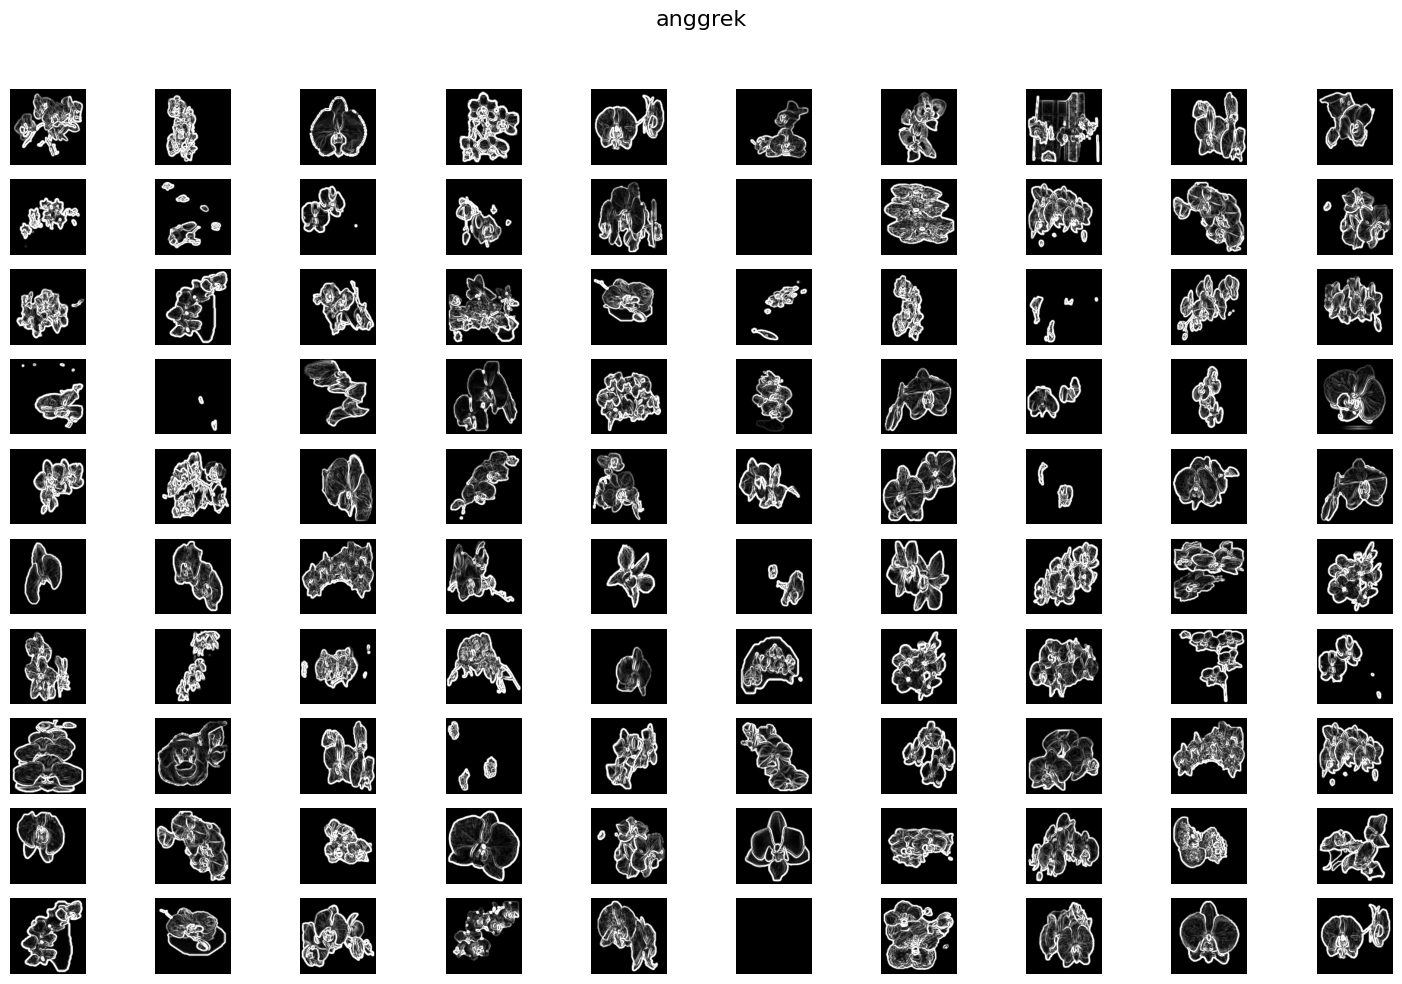

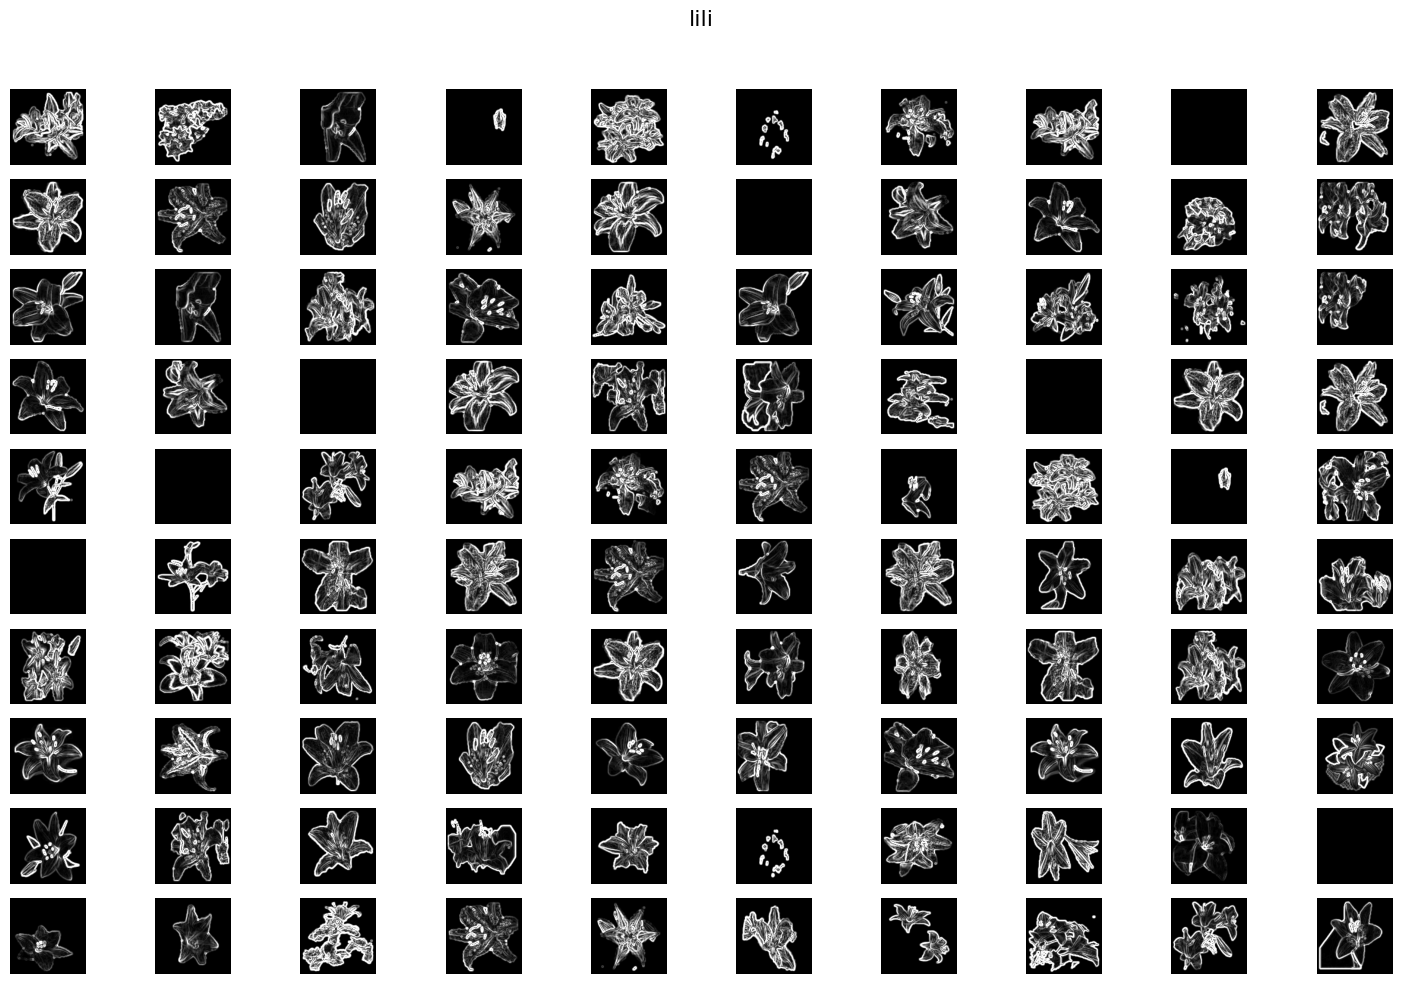

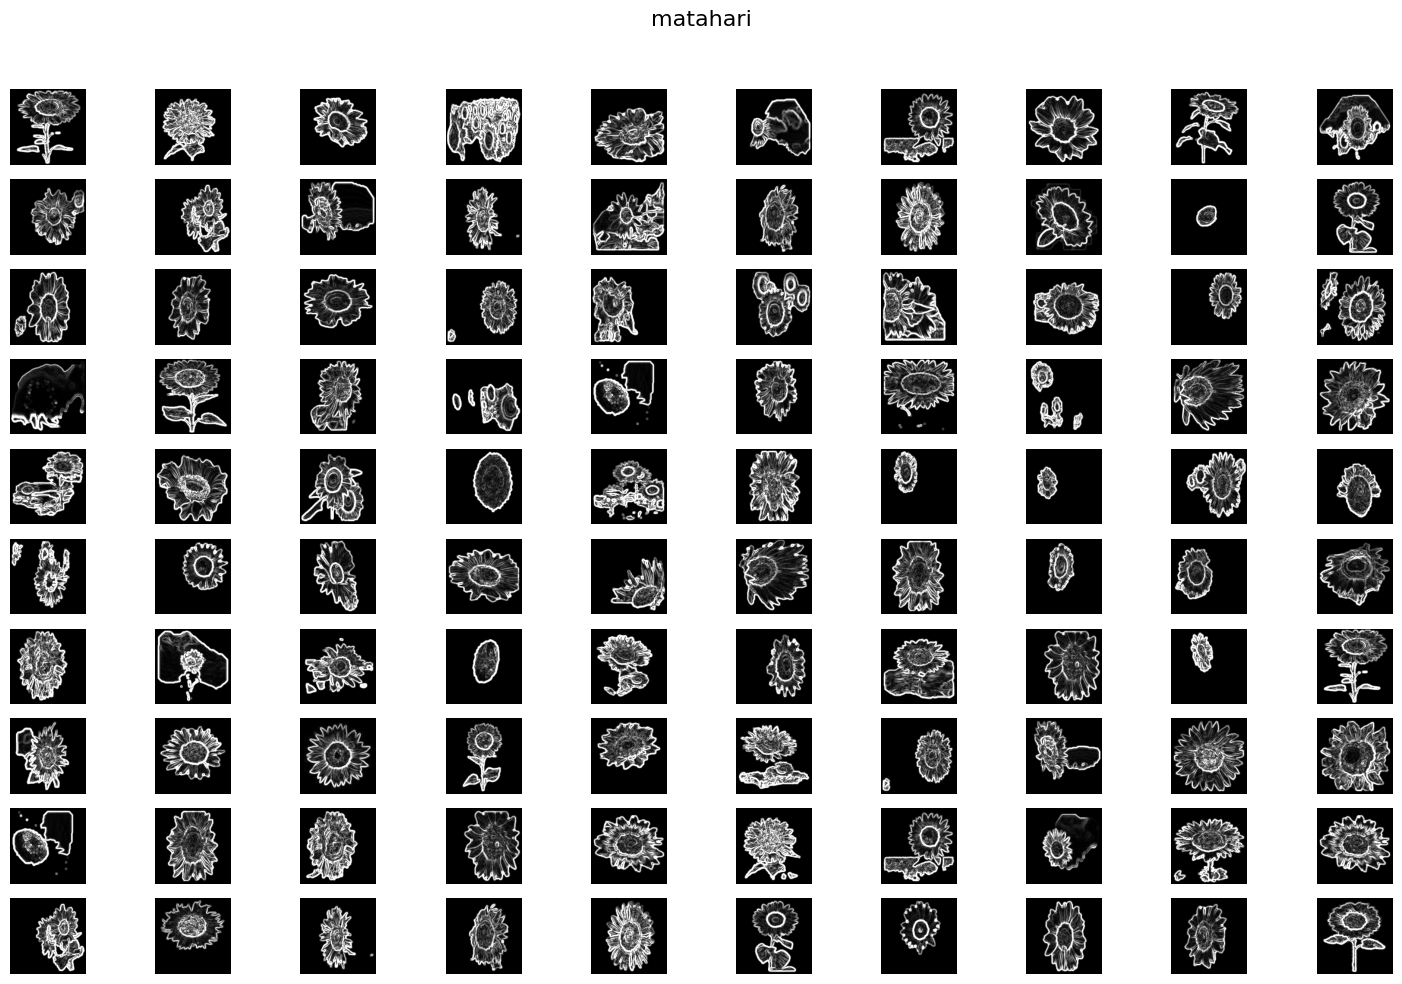

In [6]:
def percobaan3(img):
    hasil = prepro(img)
    return hasil

dataPreprocessed = [percobaan3(img) for img in data]

unique_labels = sorted(set(labels))

for label in unique_labels:
    idxs = [j for j, l in enumerate(labels) if l == label]

    fig, axs = plt.subplots(10, 10, figsize=(15, 10)) 
    fig.suptitle(f'{label}', fontsize=16)

    for k in range(min(100, len(idxs))):
        
        row = k // 10  
        col = k % 10   
        
        ax = axs[row][col]

        ax.imshow(dataPreprocessed[idxs[k]], cmap='gray')
        ax.axis('off')
        
    for k in range(len(idxs), 100):
        row = k // 10
        col = k % 10
        axs[row][col].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    plt.show()

In [7]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [8]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. It should be one of the following: 0, 45, 90, 135.")

    glcm = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm

In [9]:
def correlation_feat(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

In [10]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []

for i in range(len(dataPreprocessed)):
    D0   = glcm(dataPreprocessed[i], 0)
    D45  = glcm(dataPreprocessed[i], 45)
    D90  = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)

Kontras0, Kontras45, Kontras90, Kontras135         = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135         = [], [], [], []
ASM0, ASM45, ASM90, ASM135                         = [], [], [], []
energy0, energy45, energy90, energy135             = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))

    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))

    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))

    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))

    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))

    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

    correlation0.append(correlation_feat(Derajat0[i]))
    correlation45.append(correlation_feat(Derajat45[i]))
    correlation90.append(correlation_feat(Derajat90[i]))
    correlation135.append(correlation_feat(Derajat135[i]))

print(f"Ekstraksi fitur selesai untuk {len(dataPreprocessed)} citra.")

Ekstraksi fitur selesai untuk 300 citra.


In [11]:
dataTable = {
    'Filename': file_name, 'Label': labels,
    'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
    'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
    'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
    'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
    'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
    'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
    'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135,
}
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_pros3.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_pros3.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,anggrek_1.jpg,anggrek,2385.635704,3173.349371,1691.491019,3127.039370,0.617267,0.600390,0.624793,0.600206,...,0.304650,0.294386,0.550617,0.541435,0.551951,0.542573,0.836520,0.783510,0.884087,0.786669
1,anggrek_2.jpg,anggrek,2003.574065,2584.058652,1402.298105,2442.541137,0.774600,0.764785,0.786917,0.766495,...,0.524572,0.513289,0.721046,0.716482,0.724274,0.716442,0.863629,0.825111,0.904554,0.834689
2,anggrek_3.jpg,anggrek,1555.245817,2192.913386,1189.326280,2043.632463,0.628054,0.608607,0.634247,0.612456,...,0.305346,0.296969,0.551429,0.544837,0.552581,0.544949,0.843380,0.780422,0.880230,0.795370
3,anggrek_4.jpg,anggrek,2600.678027,3442.606237,2206.981422,3953.116126,0.616730,0.594162,0.619411,0.585696,...,0.259741,0.246413,0.508273,0.498574,0.509648,0.496400,0.862523,0.818700,0.883334,0.791815
4,anggrek_5.jpg,anggrek,2297.715920,2933.487383,1267.006521,2827.787340,0.653790,0.642632,0.675809,0.644095,...,0.349079,0.337262,0.587028,0.580001,0.590829,0.580743,0.832736,0.787552,0.907767,0.795207
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,matahari_96.jpg,matahari,1201.437377,2096.723665,1465.045891,2406.771282,0.638719,0.619396,0.633851,0.612960,...,0.338056,0.327416,0.583122,0.574235,0.581426,0.572203,0.879384,0.790659,0.852920,0.759704
296,matahari_97.jpg,matahari,856.235974,1255.689751,662.731299,1280.737181,0.759496,0.749872,0.766926,0.749658,...,0.523204,0.514460,0.722179,0.717695,0.723328,0.717259,0.862388,0.799539,0.893487,0.795540
297,matahari_98.jpg,matahari,1808.448450,2326.910410,849.812008,2245.618699,0.608884,0.598882,0.627122,0.598777,...,0.332954,0.323142,0.574240,0.568165,0.577022,0.568456,0.805604,0.751215,0.908651,0.759907
298,matahari_99.jpg,matahari,1152.680979,1720.549197,744.039616,1460.920578,0.663229,0.650084,0.669249,0.654542,...,0.411746,0.403590,0.640051,0.633610,0.641674,0.635287,0.813868,0.723808,0.879854,0.765485


Fitur sebelum seleksi : 28
Fitur setelah seleksi : 9
Fitur terpilih        : ['Contrast0', 'Contrast45', 'Contrast90', 'Homogeneity0', 'Dissimilarity0', 'Correlation0', 'Correlation45', 'Correlation90', 'Correlation135']


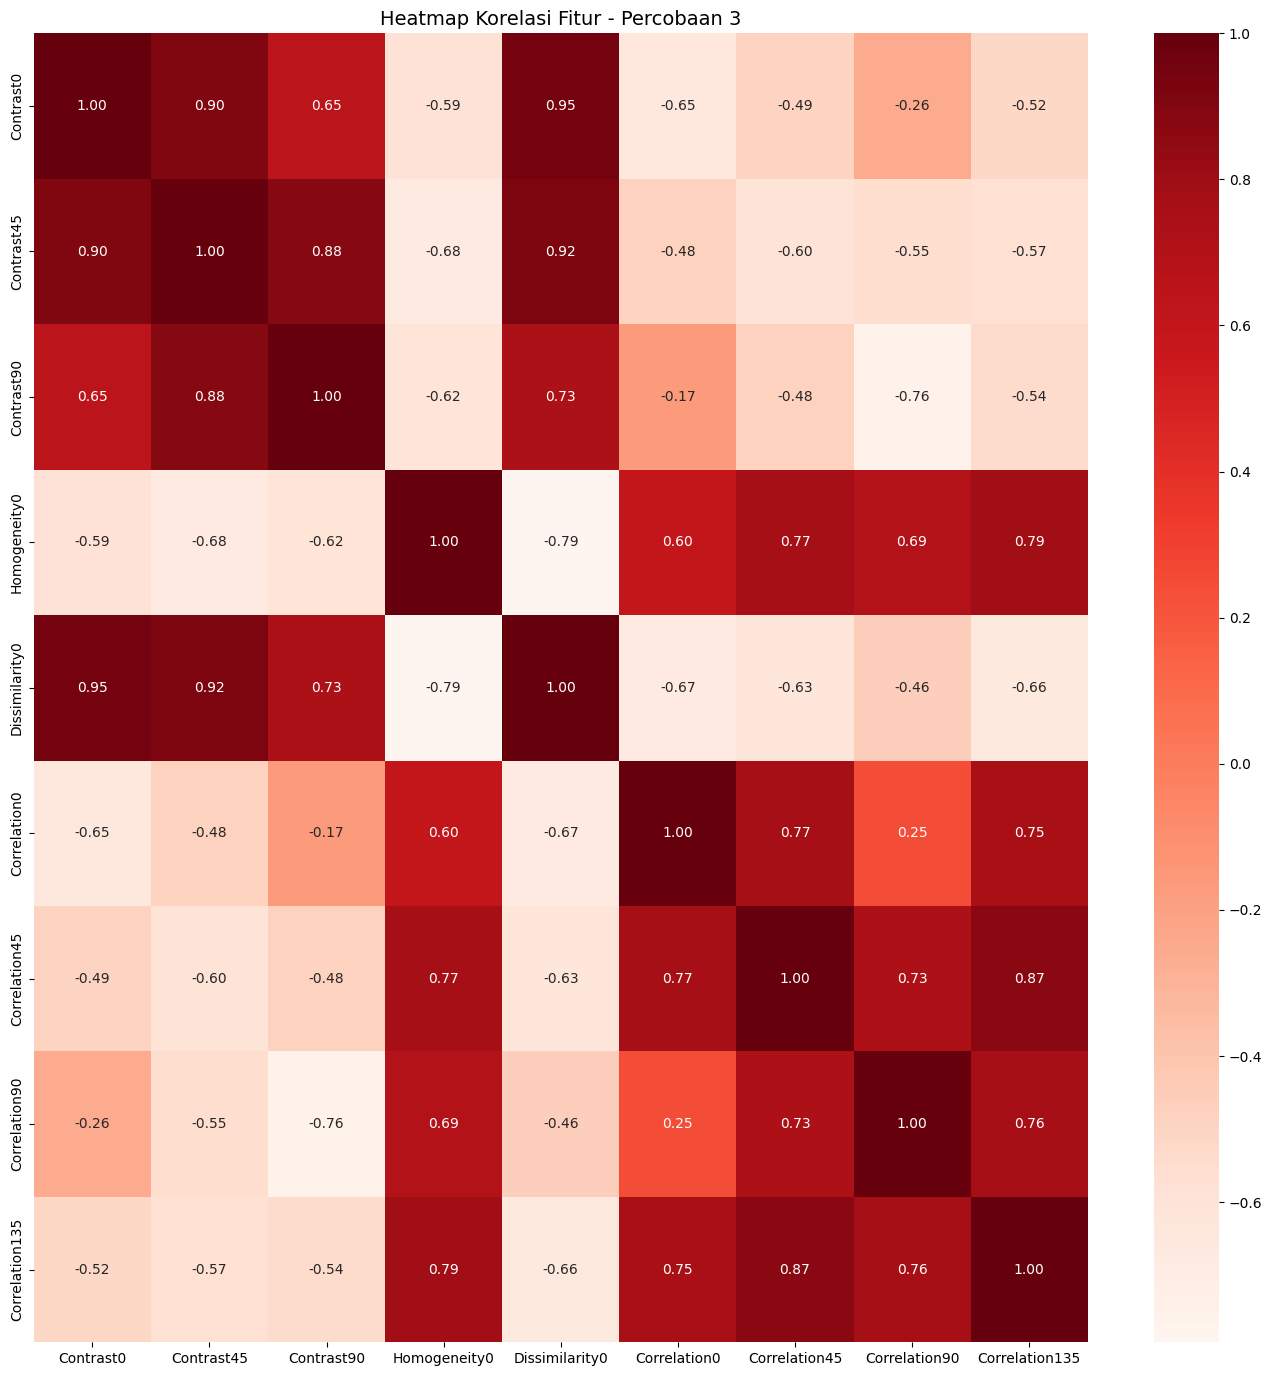

In [12]:
corr_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((corr_matrix.shape[0],), True, dtype=bool)
for i in range(corr_matrix.shape[0]):
    for j in range(i+1, corr_matrix.shape[0]):
        if abs(corr_matrix.iloc[i,j]) >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f"Fitur sebelum seleksi : 28")
print(f"Fitur setelah seleksi : {len(select)}")
print(f"Fitur terpilih        : {list(select)}")

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Reds', fmt=".2f")
plt.title('Heatmap Korelasi Fitur - Percobaan 3', fontsize=14)
plt.show()

In [13]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape)
print(X_test.shape)

(240, 9)
(60, 9)


In [14]:
mean_train = X_train.mean()
std_train  = X_train.std()

X_test  = (X_test  - mean_train) / std_train
X_train = (X_train - mean_train) / std_train

In [15]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print(confusion_matrix(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Random Forest
rf  = RandomForestClassifier(n_estimators=200, max_depth= 8, min_samples_split=4, min_samples_leaf=2, max_features='sqrt', random_state=42)
svm = SVC(kernel='rbf', random_state=42, C=5, gamma='scale', class_weight='balanced')
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')

In [16]:
# Train Random Forest Classifier
rf.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = rf.predict(X_test)
generateClassificationReport(y_test, y_pred)

------Training Set------
              precision    recall  f1-score   support

     anggrek       0.96      0.94      0.95        80
        lili       0.94      0.99      0.96        80
    matahari       0.99      0.96      0.97        80

    accuracy                           0.96       240
   macro avg       0.96      0.96      0.96       240
weighted avg       0.96      0.96      0.96       240

[[75  4  1]
 [ 1 79  0]
 [ 2  1 77]]
Accuracy: 0.9625

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.58      0.70      0.64        20
        lili       0.64      0.45      0.53        20
    matahari       0.59      0.65      0.62        20

    accuracy                           0.60        60
   macro avg       0.61      0.60      0.59        60
weighted avg       0.61      0.60      0.59        60

[[14  3  3]
 [ 5  9  6]
 [ 5  2 13]]
Accuracy: 0.6


In [17]:
# Train SVM Classifier
svm.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = svm.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       0.71      0.69      0.70        80
        lili       0.70      0.76      0.73        80
    matahari       0.70      0.66      0.68        80

    accuracy                           0.70       240
   macro avg       0.70      0.70      0.70       240
weighted avg       0.70      0.70      0.70       240

[[55 13 12]
 [ 8 61 11]
 [14 13 53]]
Accuracy: 0.7041666666666667

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.68      0.75      0.71        20
        lili       0.69      0.55      0.61        20
    matahari       0.55      0.60      0.57        20

    accuracy                           0.63        60
   macro avg       0.64      0.63      0.63        60
weighted avg       0.64      0.63      0.63        60

[[15  2  3]
 [ 2 11  7]
 [ 5  3 12]]
Accuracy: 0.6333333333333333


In [18]:
# Train KNN Classifier
knn.fit(X_train, y_train)

# Make predictions and evaluate the model with the training set
print("\n------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

# Make predictions and evaluate the model with the testing set
print("\n------Testing Set------")
y_pred = knn.predict(X_test)
generateClassificationReport(y_test, y_pred)


------Training Set------
              precision    recall  f1-score   support

     anggrek       1.00      0.97      0.99        80
        lili       0.98      1.00      0.99        80
    matahari       1.00      1.00      1.00        80

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240

[[78  2  0]
 [ 0 80  0]
 [ 0  0 80]]
Accuracy: 0.9916666666666667

------Testing Set------
              precision    recall  f1-score   support

     anggrek       0.64      0.80      0.71        20
        lili       0.70      0.35      0.47        20
    matahari       0.60      0.75      0.67        20

    accuracy                           0.63        60
   macro avg       0.65      0.63      0.61        60
weighted avg       0.65      0.63      0.61        60

[[16  2  2]
 [ 5  7  8]
 [ 4  1 15]]
Accuracy: 0.6333333333333333


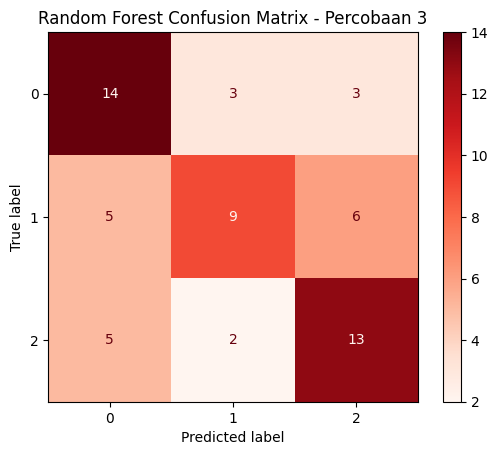

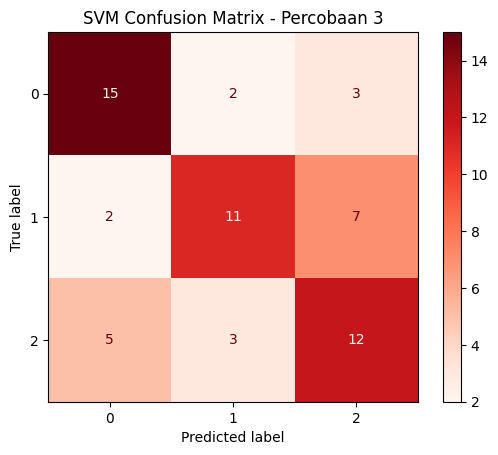

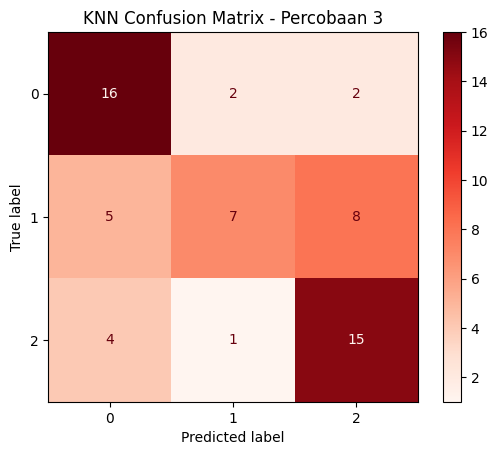

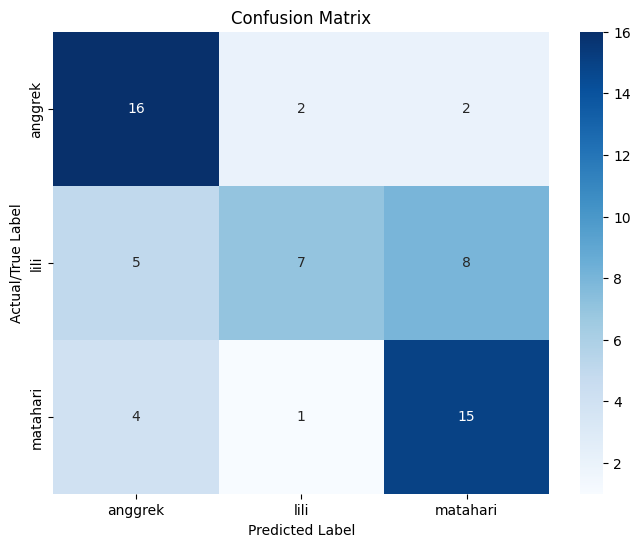

In [19]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Reds)
    plt.title(title)
    plt.show()

# Plot confusion matrix for Random Forest
plot_confusion_matrix(y_test, rf.predict(X_test),  "Random Forest Confusion Matrix - Percobaan 3")
# Plot confusion matrix for SVM
plot_confusion_matrix(y_test, svm.predict(X_test), "SVM Confusion Matrix - Percobaan 3")
# Plot confusion matrix for KNN
plot_confusion_matrix(y_test, knn.predict(X_test), "KNN Confusion Matrix - Percobaan 3")

# 1. Hitung confusion matrix-nya dulu (pastikan y_test dan y_pred sesuai dengan variabelmu)
cm = confusion_matrix(y_test, y_pred)

# 2. Ambil nama label unik untuk teks di sumbu X dan Y
class_names = sorted(set(labels)) 

# 3. Gambar Heatmap-nya
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.ylabel('Actual/True Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.show()

In [20]:
# Simpan hasil perbandingan model
hasil_klasifikasi = {
    'Model'    : ['Random Forest', 'SVM', 'KNN'],
    'Accuracy_Train': [
        accuracy_score(y_train, rf.predict(X_train)),
        accuracy_score(y_train, svm.predict(X_train)),
        accuracy_score(y_train, knn.predict(X_train)),
    ],
    'Accuracy_Test': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, svm.predict(X_test)),
        accuracy_score(y_test, knn.predict(X_test)),
    ],
    'Precision': [
        precision_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        precision_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        precision_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'Recall': [
        recall_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        recall_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        recall_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
    'F1_Score': [
        f1_score(y_test, rf.predict(X_test),  average='weighted', zero_division=0),
        f1_score(y_test, svm.predict(X_test), average='weighted', zero_division=0),
        f1_score(y_test, knn.predict(X_test), average='weighted', zero_division=0),
    ],
}
df_hasil = pd.DataFrame(hasil_klasifikasi)
df_hasil.to_csv('hasil_klasifikasi_pros3.csv', index=False)
print("✅ File hasil_klasifikasi_pros3.csv berhasil disimpan!")
df_hasil

✅ File hasil_klasifikasi_pros3.csv berhasil disimpan!


,Model,Accuracy_Train,Accuracy_Test,Precision,Recall,F1_Score
0,Random Forest,0.962500,0.600000,0.605700,0.600000,0.594941
1,SVM,0.704167,0.633333,0.638258,0.633333,0.632275
2,KNN,0.991667,0.633333,0.646667,0.633333,0.614815
